In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from irsa.io import load_spectra
from irsa.spectra import SpectraCollection
from irsa.spectra.objects import smooth_pca

import mlgrad.smooth as smooth
import mlgrad.af as af
import mlgrad.funcs as funcs
import mlgrad.inventory as inventory

import ipywidgets

import warnings
warnings.filterwarnings( "ignore") #, module = "matplotlib\..*")

# %matplotlib widget

In [17]:
import pandas as pd
df = pd.read_csv("noise/noise.csv", sep=",", )
df

,Unnamed: 0,x,y
0,"804,832214355469","3,79999995231628",NaN
1,"804,886535644531","0,249993905425072",NaN
2,"804,940856933594","1,95000612735748",NaN
3,"804,995178222656","0,450000017881393",NaN
4,"805,049499511719","1,50000607967377",NaN
...,...,...,...
2043,"915,261840820313","-6,10351571594947E-06",NaN
2044,"915,315551757813","-1,55000615119934",NaN
2045,"915,369201660156","0,799981713294983",NaN
2046,"915,422912597656","4,25",NaN


In [2]:

dd = SpectraCollection()
dd.load("/home/intellimath/work/spectra/13", "origin")
keys = list(dd.keys())
x = dd[keys[0]].x
ys = dd[keys[0]].y
y = ys[0]
# y_max = y.max()
# y /= y_max

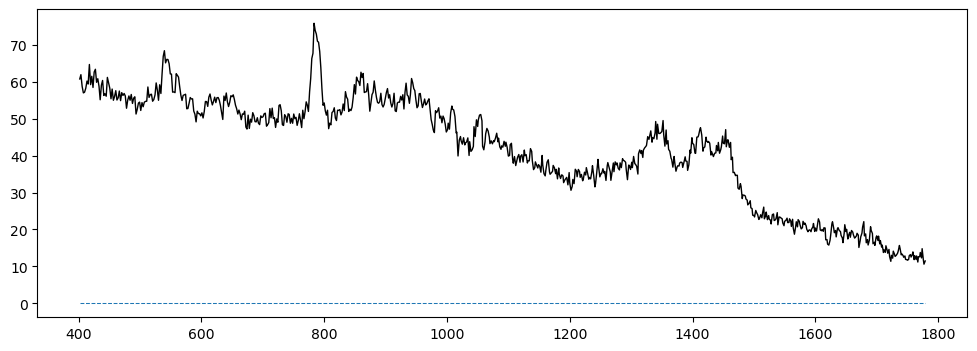

In [3]:
plt.figure(figsize=(12,4))
plt.plot(x, y, color='k', linewidth=1.0)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.show()

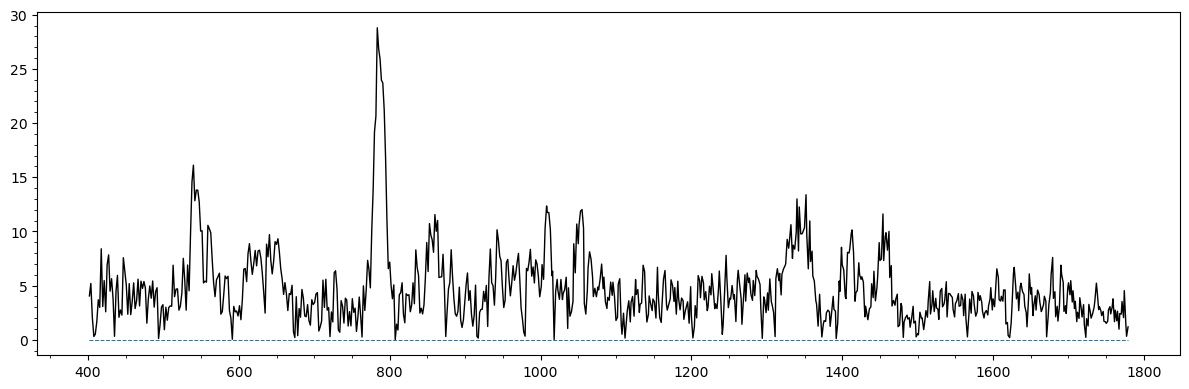

In [4]:
bl, _ = smooth.whittaker_smooth_weight_func2(
        y,func=funcs.Step(0.00, eps=0.001),
        # func2=funcs.Step(0.00, eps=0.001),
        # func2_e=inventory.relative_abs_max,
        tau2=1.0e6, d=4)
y_bl = y - bl
y_bl -= y_bl.min()
# y_bl /= y_bl.mean()
# y_bl *= 10
plt.figure(figsize=(12,4))
plt.plot(x, y_bl, color='k', linewidth=1.0)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.tight_layout()
plt.minorticks_on()
plt.show()

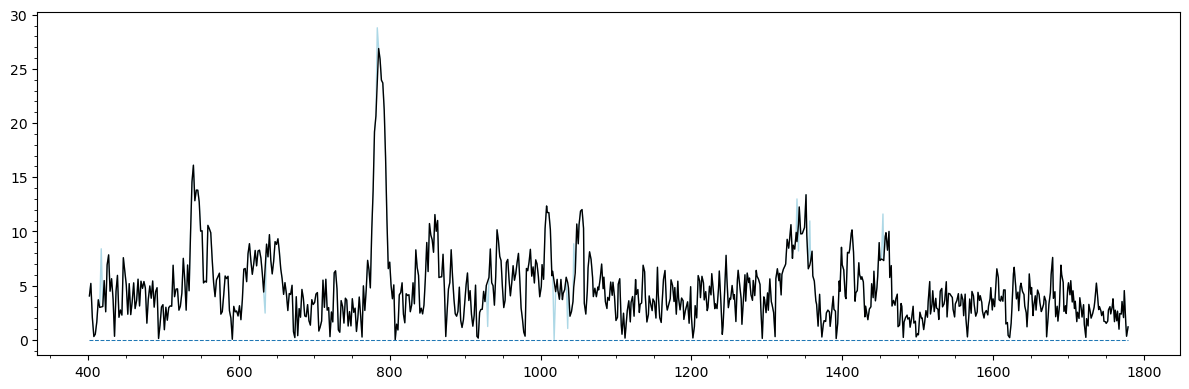

In [11]:
from irsa.spectra.objects import despike
plt.figure(figsize=(12,4))
plt.plot(x, y_bl, color='lightblue', linewidth=1.0)
plt.plot(x, despike(y_bl, 3.0), color='k', linewidth=1.0)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.tight_layout()
plt.minorticks_on()
plt.show()

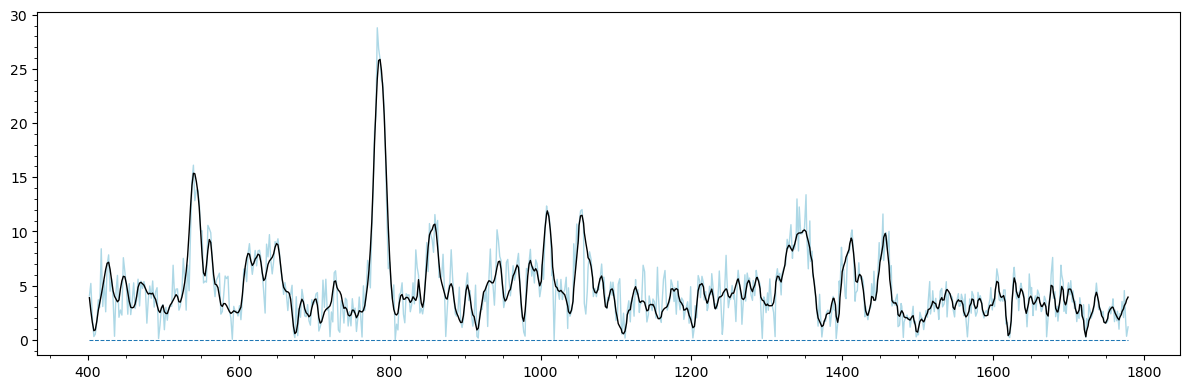

In [21]:
y_bl_sm, _ = smooth.whittaker_smooth_ex(y_bl, tau2=0.5, aggfunc=af.averaging_function("WMZ", kwds={"alpha":3.0}))
plt.figure(figsize=(12,4))
plt.plot(x, y_bl, color='lightblue', linewidth=1.0)
plt.plot(x, y_bl_sm, color='k', linewidth=1.0)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.tight_layout()
plt.minorticks_on()
plt.show()

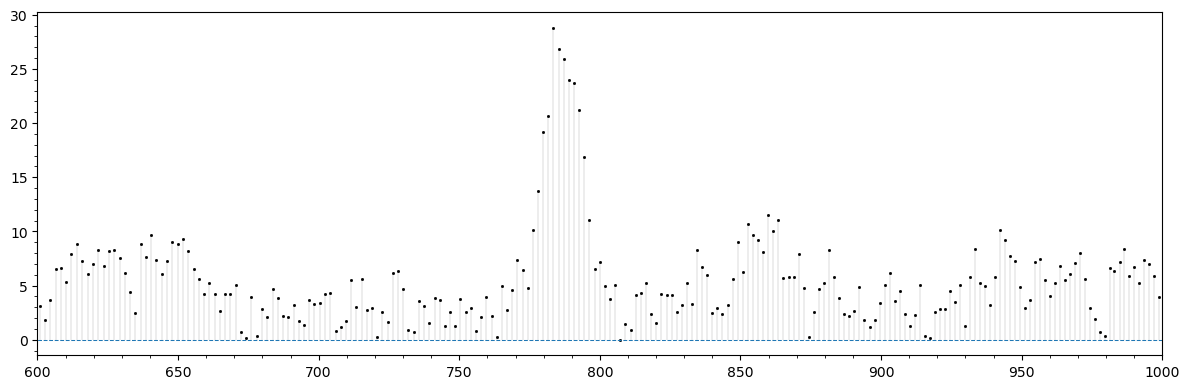

In [12]:
plt.figure(figsize=(12,4))
plt.plot(x, y_bl, color='k', lw=0, marker='s', ms=1.0)
plt.vlines(x, 0, y_bl, color='k', linewidth=0.1)
plt.hlines(0, x.min(), x.max(), ls='--', lw=0.75)
plt.xlim(600,1000)
plt.tight_layout()
plt.minorticks_on()
plt.show()

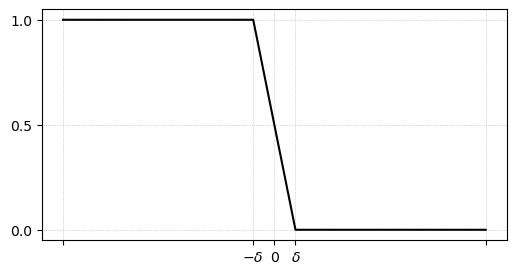

In [13]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,-0.2,0,0.2,2],[1,1,0.5,0,0], color='k')
plt.xticks([-2,-0.2,0, 0.2,2],['',r'$-\delta$', 0, r'$\delta$', ''])
plt.yticks([1,0.5,0])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_delta.eps")
plt.show()

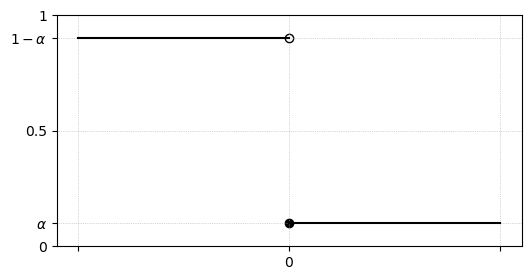

In [14]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,0],[0.9,0.9], color='k')
plt.plot([0,2],[0.1,0.1], color='k')
plt.scatter([0],[0.1], c='k')
plt.scatter([0],[0.9], c='w', edgecolors='k')
plt.xticks([-2,0,2],['', 0,  ''])
plt.yticks([1, 0.9,0.5,0.1,0], [1,r'$1-\alpha$',0.5,r'$\alpha$',0])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/expectile.eps")
plt.show()

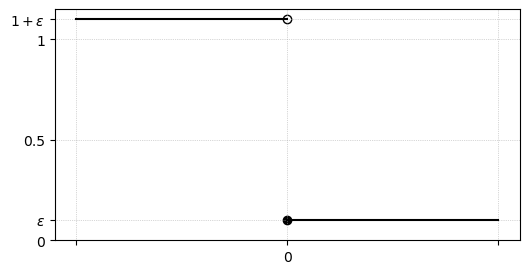

In [15]:
plt.figure(figsize=(6,3.0))
plt.plot([-2,0],[1.1,1.1], color='k')
plt.plot([0,2],[0.1,0.1], color='k')
plt.scatter([0],[0.1], c='k')
plt.scatter([0],[1.1], c='w', edgecolors='k')
plt.xticks([-2,0,2],['', 0,  ''])
plt.yticks([1.1, 1,0.5,0.1,0], [r'$1+\epsilon$',1,0.5,r'$\epsilon$',0])
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_epsilon.eps")
plt.show()

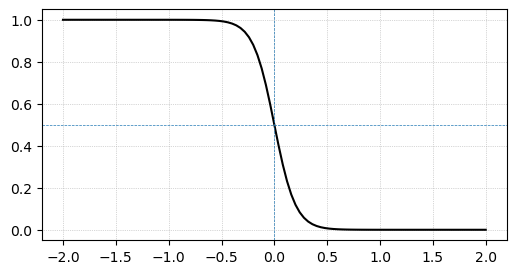

In [16]:
plt.figure(figsize=(6,3.0))
xr = np.linspace(-2,2,101)
plt.plot(xr,funcs.Logistic(-0.1).evaluate_array(xr), color='k')
plt.axhline(0.5, lw=0.5, ls='--')
plt.axvline(0, lw=0.5, ls='--')
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/step_expit.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


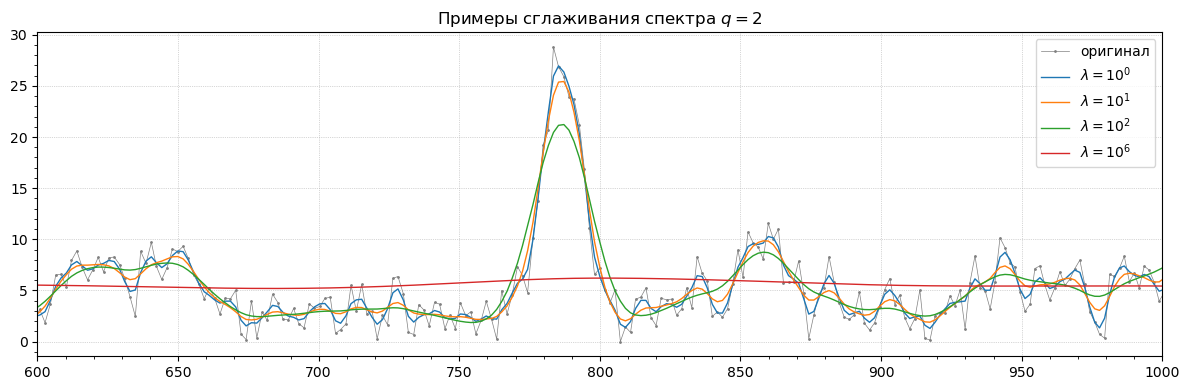

In [17]:
js = [0, 1, 2, 6]
colors1 = ["red", "blue", "green","brown"]
colors2 = ["darkred", "darkblue", "darkgreen", "magenta"]
zs = [smooth.whittaker_smooth(y_bl, tau2=10**j, d=2) for j in js]

plt.figure(figsize=(12,4))
plt.title(r"Примеры сглаживания спектра $q=2$")
plt.plot(x, y_bl, color='gray', linewidth=0.5, marker='o', ms=1.0, label="оригинал")
for i,z in enumerate(zs):
    plt.plot(x, z, linewidth=1.0, label=r"$\lambda=$"+ r"$10^{%s}$" % js[i])
# plt.xlabel("t")
# plt.ylabel("x")
plt.xlim(600,1000)
plt.minorticks_on()
plt.tight_layout()
plt.grid(ls=':', lw=0.5)
plt.legend()
plt.savefig("fig/smooth1.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


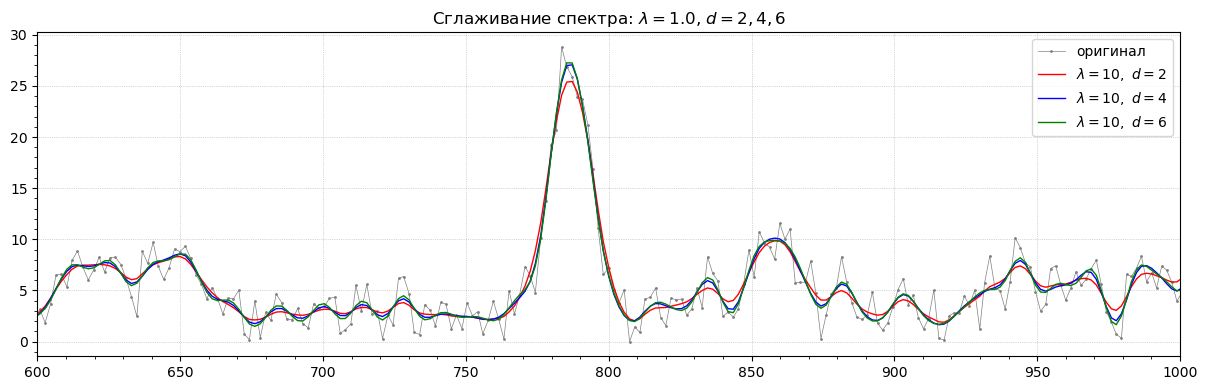

In [18]:
ds = [2,4,6]
colors1 = ["red", "blue", "green"]
colors2 = ["darkred", "darkblue", "darkgreen"]
softabs_func = funcs.SoftAbs(0.001)
abs_func = funcs.Abs()
zs1 = [smooth.whittaker_smooth_weight_func2(y_bl, tau2=10.0, 
                                            # func=softabs_func.derivative_div_array, 
                                            # func2=softabs_func.derivative_div_array, 
                                            d=d)[0] \
     for d in ds]
# zs2 = [smooth.whittaker_smooth_weight_func2(y_bl, tau2=10**12, 
#                                             # func=softabs_func.derivative_div_array, 
#                                             # func2=softabs_func.derivative_div_array, 
#                                             d=d)[0] \
#      for d in ds]

plt.figure(figsize=(12,4))
plt.title(r"Сглаживание спектра: $\lambda=1.0$, $d=2,4,6$")
plt.plot(x, y_bl, color='gray', linewidth=0.5, marker='o', ms=1.0, label="оригинал")
for i,z in enumerate(zs1):
    plt.plot(x, z, color=colors1[i], linewidth=1.0, label=r"$\lambda=10,\ d=$" + f"{ds[i]}")
plt.minorticks_on()
plt.tight_layout()
plt.xlim(600,1000)
plt.legend()
plt.grid(ls=':', lw=0.5)
plt.savefig("fig/smooth2.eps")
plt.show()

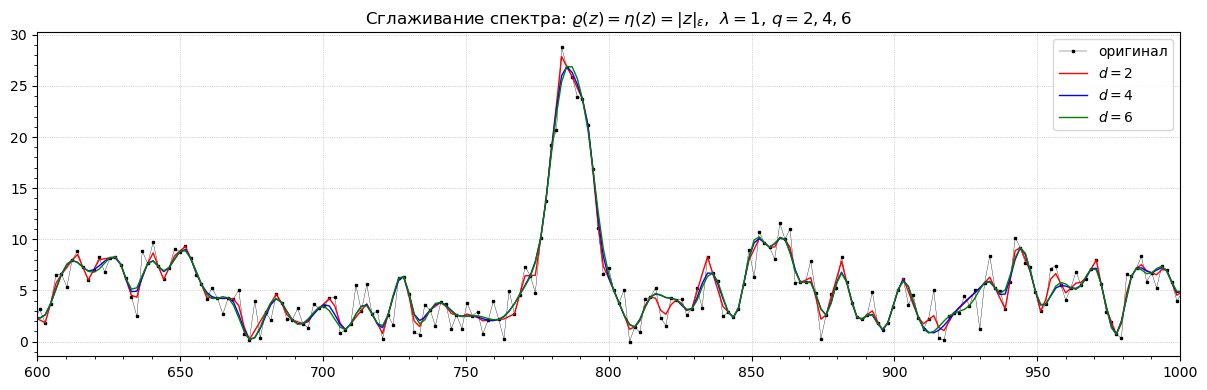

In [22]:
ds = [2,4,6]
colors1 = ["red", "blue", "green"]
colors2 = ["darkred", "darkblue", "darkgreen"]
softabs_func = funcs.SoftAbs(0.00001)
sq_func = funcs.Square()
# func_lc = funcs.LinearComp(sq_func, softabs_func, 0.1, 1.0)
abs_func = funcs.Abs()
zs = [smooth.whittaker_smooth_weight_func2(y_bl, tau2=0.5, 
                                            func=softabs_func.derivative_div_array, 
                                            func2=softabs_func.derivative_div_array, 
                                            d=d)[0] \
     for d in ds]

plt.figure(figsize=(12,4))
plt.title(r"Сглаживание спектра: $\varrho(z)=\eta(z)=|z|_\epsilon$,  $\lambda=1$, $q=2,4,6$")
plt.plot(x, y_bl, color='k', linewidth=0.25, marker='s', ms=2.0, label="оригинал")
for i,z in enumerate(zs):
    plt.plot(x, z, color=colors1[i], linewidth=1.0, label=r"$d=$" + f"{ds[i]}")
# plt.xlabel("t")
# plt.ylabel("x")
plt.minorticks_on()
plt.tight_layout()
plt.xlim(600,1000)
plt.legend()
plt.grid(ls=':', lw=0.5)
plt.show()

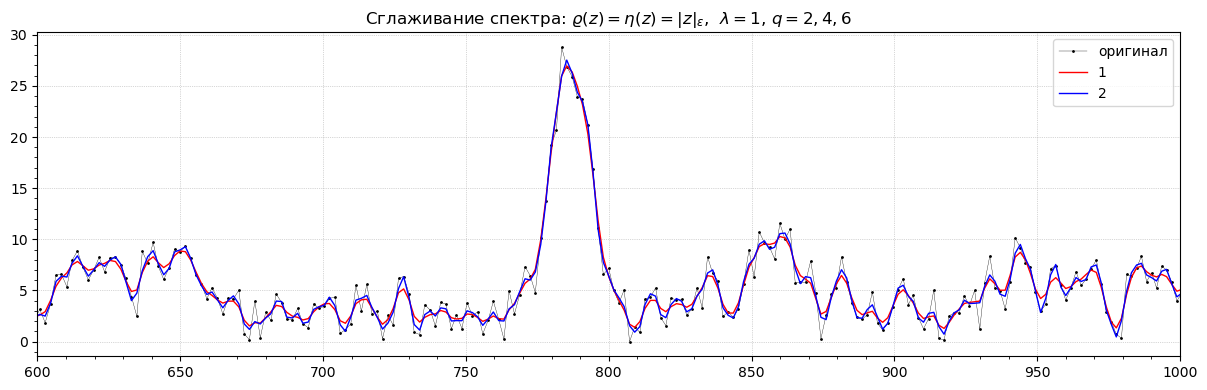

In [13]:
ds = [2,4,6]
colors1 = ["red", "blue", "green"]
# colors2 = ["darkred", "darkblue", "darkgreen"]
softabs_func = funcs.SoftAbs(0.00001)
sq_func = funcs.Square()
abs_func = funcs.Abs()

def gauss_func2(Z, s=5):
    return np.exp(-2*abs(Z) / s)

zs1, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, d=2)
zs2, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, func2_e=inventory.relative_abs_max, d=2)
plt.figure(figsize=(12,4))
plt.title(r"Сглаживание спектра: $\varrho(z)=\eta(z)=|z|_\epsilon$,  $\lambda=1$, $q=2,4,6$")
plt.plot(x, y_bl, color='k', linewidth=0.25, marker='o', ms=1.0, label="оригинал")
plt.plot(x, zs1, color="r", linewidth=1.0, label="1")
plt.plot(x, zs2, color="b", linewidth=1.0, label="2")
# plt.xlabel("t")
# plt.ylabel("x")
plt.minorticks_on()
plt.tight_layout()
plt.xlim(600,1000)
plt.legend()
plt.grid(ls=':', lw=0.5)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


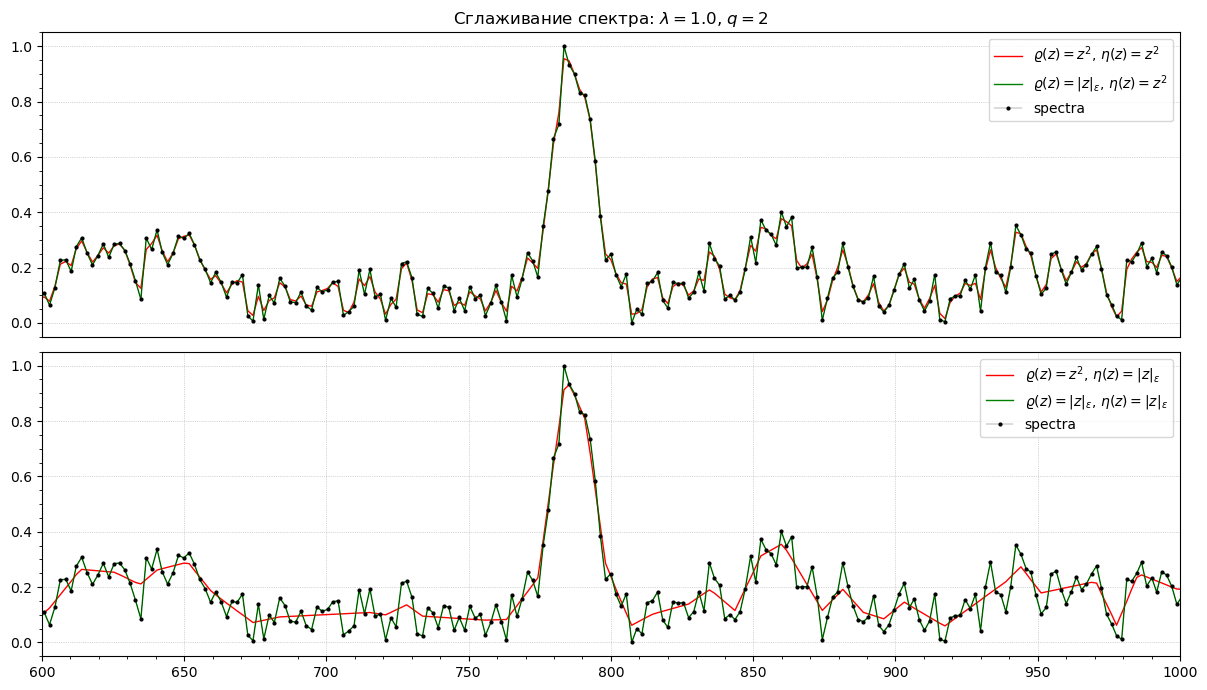

In [29]:
tau = 0.1
d=2
y_max = y_bl.max()
y_bl1 = y_bl / y_max
z4, _ = smooth.whittaker_smooth_weight_func2(y_bl1, tau2=tau, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=d)
z3, _ = smooth.whittaker_smooth_weight_func2(y_bl1, tau2=tau, 
                                          func=sq_func.derivative_div_array, 
                                          func2=softabs_func.derivative_div_array, 
                                          d=d)
z2, _ = smooth.whittaker_smooth_weight_func2(y_bl1, tau2=tau, 
                                          func=softabs_func.derivative_div_array, 
                                          func2=sq_func.derivative_div_array, 
                                          d=d)
z = smooth.whittaker_smooth(y_bl1, tau2=tau, d=d)


plt.figure(figsize=(12,7))
plt.subplot(2,1,1)
plt.plot(x, z, lw=1.0, color='r', 
         label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
plt.plot(x, z2, lw=1.0, color='g', 
         label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=z^2$")
plt.plot(x, y_bl1, color='k', lw=0.2, marker='o', ms=2, label='spectra')
plt.title(r"Сглаживание спектра: $\lambda=1.0$, $q=2$")
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xticks([])
plt.xlim(600,1000)
plt.subplot(2,1,2)
plt.plot(x, z3, lw=1.0, color='r', 
         label=r"$\varrho(z)=z^2$, $\eta(z)=|z|_\epsilon$")
plt.plot(x, z4, lw=1.0, color='g', 
         label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
plt.plot(x, y_bl1, color='k', lw=0.2, marker='o', ms=2, label='spectra')
# plt.title(r"Сглаживание спектра: $\lambda=1.0$, $q=2$")
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xlim(600,1000)
plt.savefig("fig/smooth3.eps")
plt.show()
# plt.figure(figsize=(10,3))
# plt.plot(sorted(abs(inventory.zscore(abs(z-y_bl)))), color="r", label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
# plt.plot(sorted(abs(inventory.zscore(abs(z2-y_bl)))), color="g", label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
# plt.hlines(3.0, 0, len(y_bl), ls='--')
# plt.hlines(3.5, 0, len(y_bl), ls='--')
# plt.legend()
# plt.tight_layout()
# plt.minorticks_on()
# plt.grid(ls=':', lw=0.5)
# plt.show()

In [15]:
# z4, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=1.0, 
#                                           func=softabs_func.derivative_div_array, 
#                                           func2=softabs_func.derivative_div_array, 
#                                           d=4)
# # z3, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=tau, 
# #                                           func=sq_func.derivative_div_array, 
# #                                           func2=softabs_func.derivative_div_array, 
# #                                           d=4)
# # z2, _ = smooth.whittaker_smooth_weight_func2(y_bl, tau2=tau, 
# #                                           func=softabs_func.derivative_div_array, 
# #                                           func2=sq_func.derivative_div_array, 
# #                                           d=2)
# z = smooth.whittaker_smooth(y_bl, tau2=1.0, d=4)
# # zz = smooth_pca(y_bl, n_component=0.95)


# plt.figure(figsize=(12,5))
# plt.plot(x, z, lw=1.0, color='brown', 
#          label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
# plt.plot(x, z4, lw=1.0, color='b',
#          label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
# # plt.plot(zz, lw=1.0, color='b',
# #          label=r"pca")
# plt.plot(x, y_bl, color='k', lw=0.2, marker='o', ms=2, label='spectra')
# plt.legend()
# plt.tight_layout()
# plt.minorticks_on()
# plt.grid(ls=':', lw=0.5)
# plt.xlim(600,1000)
# plt.savefig("fig/smooth4.eps")
# plt.show()
# # plt.figure(figsize=(10,4))
# # plt.plot(sorted(abs(inventory.zscore(abs(z-y_bl)))), label=r"$\varrho(z)=z^2$, $\eta(z)=z^2$")
# # plt.plot(sorted(abs(inventory.zscore(abs(z4-y_bl)))), label=r"$\varrho(z)=|z|_\epsilon$, $\eta(z)=|z|_\epsilon$")
# # plt.hlines(3.0, 0, len(y_bl), ls='--')
# # plt.hlines(3.5, 0, len(y_bl), ls='--')
# # plt.legend()
# # plt.tight_layout()
# # plt.minorticks_on()
# # plt.grid(ls=':', lw=0.5)
# # plt.show()

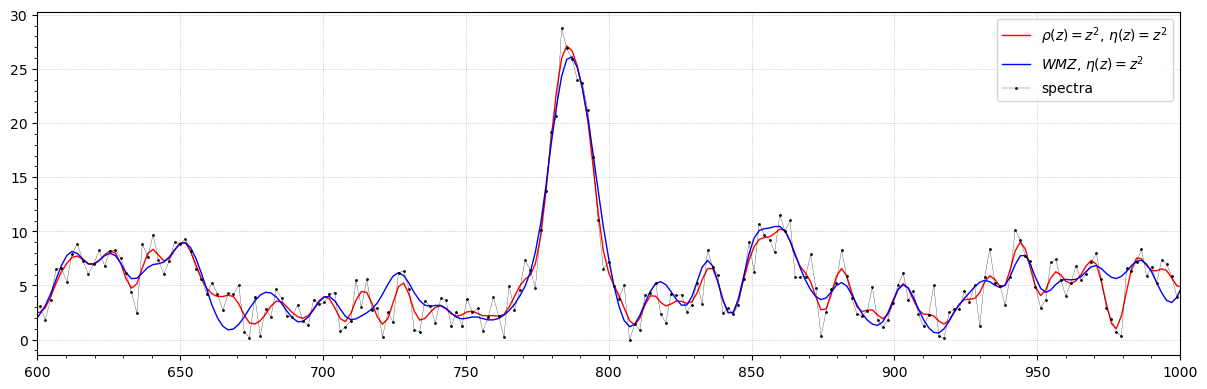

In [16]:
from mlgrad.af import averaging_function
softabs_func = funcs.SoftAbs(0.001)
sq_func = funcs.Square()
tau = 1.0

z2, _ = smooth.whittaker_smooth_ex(y_bl, tau2=tau, 
                            aggfunc=averaging_function("WMZ", kwds={"alpha":3.5}),
                            aggfunc2=averaging_function("AM"),
                            # func=funcs.Abs(),
                            func=sq_func,
                            func2=sq_func,
                            d=4)
z = smooth.whittaker_smooth(y_bl, tau2=1.0, d=4)


plt.figure(figsize=(12,4))
plt.plot(x, z, lw=1.0, color='r', 
         label=r"$\rho(z)=z^2$, $\eta(z)=z^2$")
plt.plot(x, z2, lw=1.0, color='b', 
         label=r"$WMZ$, $\eta(z)=z^2$")
plt.plot(x, y_bl, color='k', lw=0.2, marker='o', ms=1, label='spectra')
plt.legend()
plt.tight_layout()
plt.minorticks_on()
plt.grid(ls=':', lw=0.5)
plt.xlim(600,1000)
plt.show()
# plt.figure(figsize=(10,4))
# plt.plot(sorted(abs(inventory.modified_zscore(abs(z-y_bl)))), color='r', label=r"$\rho(z)=z^2$, $\eta(z)=z^2$")
# plt.plot(sorted(abs(inventory.modified_zscore(abs(z2-y_bl)))), color='g', label=r"$WMZ$, $\eta(z)=z^2$")
# plt.hlines(3.0, 0, len(y_bl), ls='--')
# plt.hlines(3.5, 0, len(y_bl), ls='--')
# plt.legend()
# plt.tight_layout()
# plt.minorticks_on()
# plt.grid(ls=':', lw=0.5)
# plt.show()

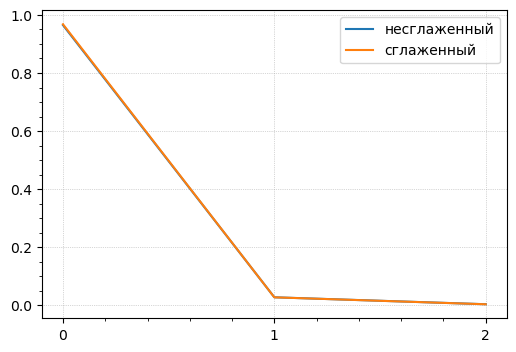

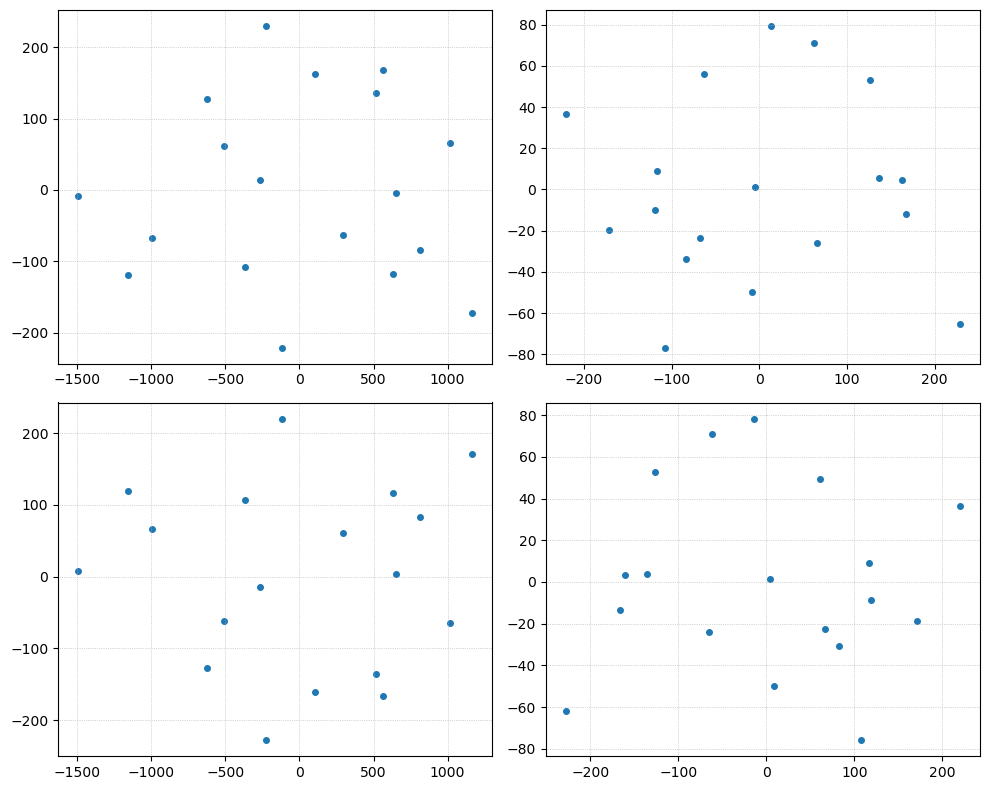

In [17]:
from sklearn.decomposition import PCA

zs = [smooth.whittaker_smooth(y, tau2=1.0, d=2) for y in ys]
pca_ys = PCA().fit(ys)
us_ys = pca_ys.transform(ys)
pca_zs = PCA().fit(zs)
us_zs = pca_zs.transform(zs)

plt.figure(figsize=(6,4))
plt.plot(pca_ys.explained_variance_ratio_[:3], label="несглаженный")
plt.plot(pca_zs.explained_variance_ratio_[:3], label="сглаженный")
plt.grid(ls=':', lw=0.5)
plt.minorticks_on()
plt.xticks([0,1,2])
plt.legend()
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.scatter(us_ys[:,0], us_ys[:,1], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,2)
plt.scatter(us_ys[:,1], us_ys[:,2], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,3)
plt.scatter(us_zs[:,0], us_zs[:,1], s=16)
plt.grid(ls=':', lw=0.5)
plt.subplot(2,2,4)
plt.scatter(us_zs[:,1], us_zs[:,2], s=16)
plt.grid(ls=':', lw=0.5)
plt.tight_layout()
# plt.legend()
plt.show()

In [18]:
tau2_slider = ipywidgets.FloatSlider(value=1.0e3, min=0, max=1.0e8, step=100)
tau2_slider.layout.width="50%"
alpha_slider = ipywidgets.FloatSlider(value=0.1, min=0.0, max=30.0, step=0.1, readout_format=".3f")
alpha_slider.layout.width="50%"

@ipywidgets.interact(tau2=tau2_slider, alpha=alpha_slider, continuous_update=False)
def plot_baseline(tau2,alpha):
    if alpha == 0:
        alpha = 1.0e-5
    elif alpha == 1:
        alpha = 1 - 1.0e-5
    y1 = y
    # y1 /= y1.max()
    # y1 = smooth.whittaker_smooth(y, tau2=10.0, d=2)
    bl1, _ = smooth.whittaker_smooth_weight_func2(
            y1, 
            # func=funcs.Quantile(alpha),
            func=funcs.Step(alpha, eps=0.000),
            # func=funcs.Weibul(alpha),
            # func=funcs.Exp(-alpha),
            # func2=funcs.Step(0.000, eps=alpha),
            # func2=softabs_func.derivative_div_array,
            func2_e=inventory.relative_abs_max,
            tau2=tau2, d=2)
    bl2, _ = smooth.whittaker_smooth_weight_func2(
            y1, func=smooth.func_aspls,
            # func2=funcs.StepRight(0.0, eps=0.001),
            func2_e=inventory.relative_abs_max,
            tau2=tau2, d=2)
    
    plt.figure(figsize=(12,7))
    plt.subplot(2,1,1)
    plt.title(r"Поиск базовой линии спектра: $\lambda=%.0f$ $\alpha=%.1f$" % (tau2, alpha))
    plt.plot(x, y1, color='k', linewidth=0.5,  ms=2.0, label="оригинал")
    plt.plot(x, bl1, linewidth=1.5, label=r"stepls")
    plt.plot(x, bl2, linewidth=1.5, label=r"aspls")
    plt.minorticks_on()
    plt.grid(ls=':', lw=0.5)
    plt.legend()
    plt.subplot(2,1,2)    
    plt.title("Разность между спектром и его базовой линией")
    plt.plot(x, y1-bl1, linewidth=1.0, label="stepPLS")
    plt.plot(x, y1-bl2, linewidth=1.0, label="asPLS")
    plt.minorticks_on()
    plt.grid(ls=':', lw=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig/bl_step_aspls.eps")
    plt.show()

interactive(children=(FloatSlider(value=1000.0, description='tau2', layout=Layout(width='50%'), max=100000000.…

In [19]:
0.5*1/36

0.013888888888888888

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


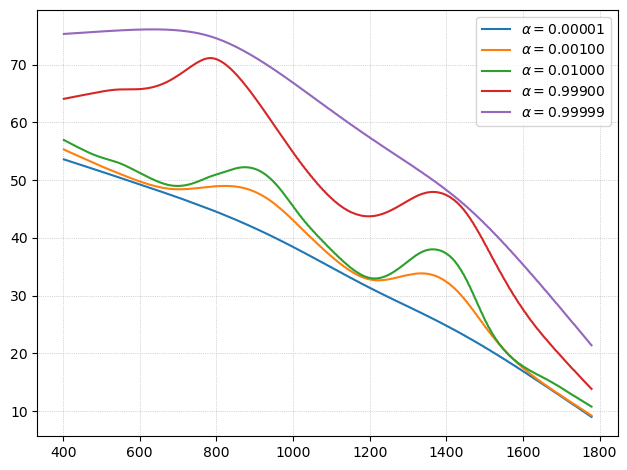

In [20]:
plt.figure(figsize=(10,4))
plt.plot(x, y, color='gray', linewidth=1.0,  ms=1.0, label="оригинал")
for alpha in [1.0e-5, 0.001, 0.01, 0.999, 1-1.0e-5]:
    bl, _ = smooth.whittaker_smooth_weight_func2(
        y, 
        func=funcs.Quantile(alpha),
        # func=funcs.Step(0.0, eps=0.001),
        # func=funcs.Weibul(alpha),
        # func=funcs.Exp(-0.5),
        # func2=funcs.Step(0.001, alpha),
        # func2_e=inventory.relative_abs_max,
        tau2=1.0e5, d=2)
    plt.plot(x, bl, linewidth=1.5, label=r"$\alpha=$"+f"{alpha:.5f}")
plt.legend()
plt.tight_layout()
plt.grid(ls=':', lw=0.5)
# plt.xlabel("t")
# plt.ylabel("x")
plt.savefig("fig/bl_asls_alpha.eps")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


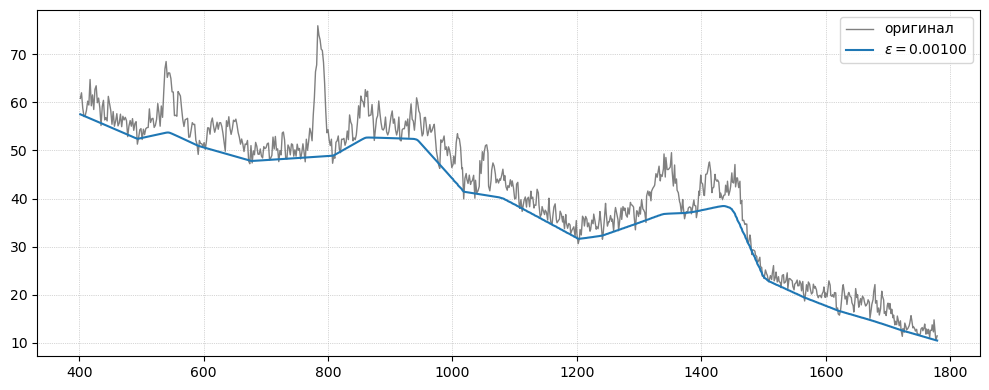

In [57]:
eps = 1.0e-3
plt.figure(figsize=(10,4))
plt.plot(x, y, color='gray', linewidth=1.0,  ms=1.0, label="оригинал")
bl, _ = smooth.whittaker_smooth_weight_func2(
    y, 
    # func=funcs.Quantile(alpha),
    func=funcs.Step(0.0, eps=1.0e-2),
    # func=funcs.Weibul(alpha),
    # func=funcs.Exp(-0.5),
    # func2=funcs.Step(0.5, eps),
    func2=softabs_func.derivative_div_array, 
    # func2_e=inventory.relative_abs_max,
    tau2=1.0e1, d=2)
plt.plot(x, bl, linewidth=1.5, label=r"$\epsilon=$"+f"{eps:.5f}")
plt.legend()
plt.tight_layout()
plt.grid(ls=':', lw=0.5)
# plt.xlabel("t")
# plt.ylabel("x")
plt.savefig("fig/bl_step_epsilon.eps")
plt.show()
